# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [16]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [17]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

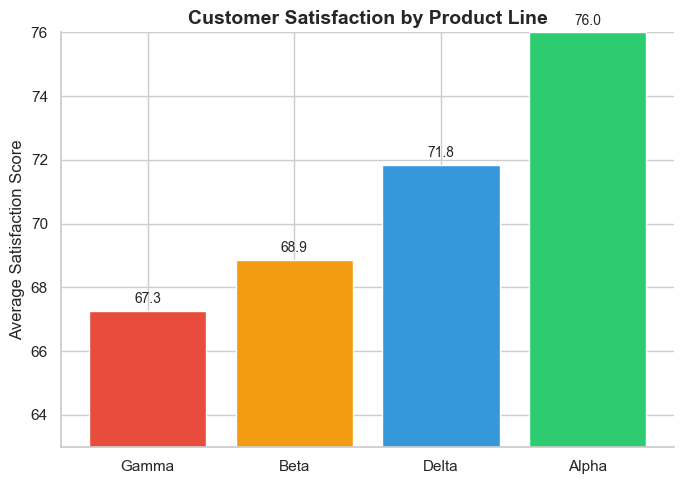

In [18]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*


Explanation: By setting the y-axis limits between 63 and 76, the chart hides the first 63 units of value, which dramatically overemphasizes the differences between the product lines. It leads the audience to believe that the red-colored product is performing catastrophically compared to the green-colored product, when in reality, all products are clustered within a relatively narrow range of high satisfaction.

Distortion Estimate: Visually, the "Green" bar appears roughly 5× to 6× taller than the "Red" bar because the visible portion represents only the tip of the data. However, the actual numerical difference between a score of ~64 and ~75 is only about 17%.

### Misleading Chart 2 — Dual-Axis Trick

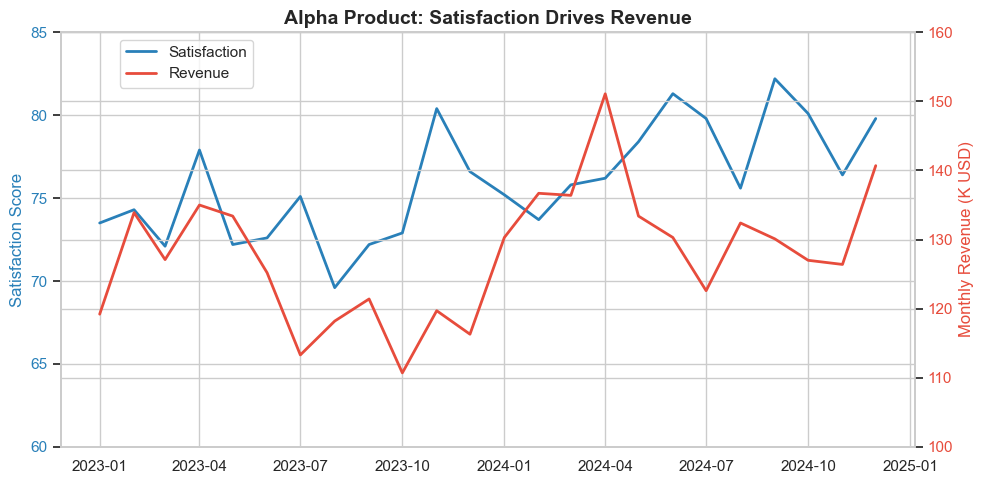

In [19]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*


Explanation: By plotting Satisfaction Score and Monthly Revenue on two separate y-axes and manually adjusting their limits ($60–85$ vs. $100–160$), the chart forces the two lines to overlap and move in visual unison. This leads the audience to believe there is a direct, near-perfect correlation (as suggested by the title "Satisfaction Drives Revenue"), even though the variables use entirely different units and scales.Distortion Estimate: The visual alignment suggests a 1:1 relationship, but because the scales are arbitrary, a small 3-point dip in satisfaction is made to look identical to a $10,000 drop in revenue. If the axes were scaled differently, the lines could easily be made to look completely unrelated.

### Misleading Chart 3 — Cherry-Picked Time Range

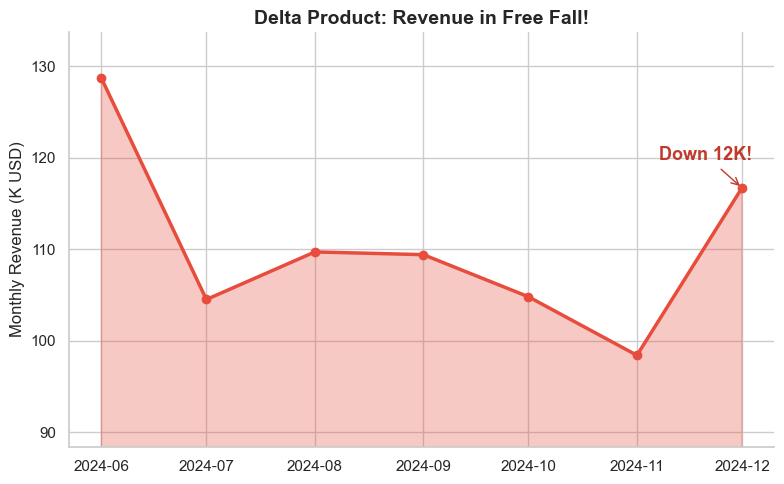

In [20]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*

Deception Technique: Cherry-Picking (Selective Time Window)

Explanation: By isolating only the months from June to December 2024, the chart creates a narrative of a "free fall" in revenue. This leads the audience to believe the product is failing, while hiding the broader context of the full year—which might show that this is a predictable seasonal dip or that revenue is still significantly higher than it was at the start of the year.

Distortion Estimate: By narrowing the window to a period of decline and tightening the y-axis, the visual slope suggests a terminal collapse. If the full year's data shows revenue fluctuates between 100K and 200K, showing only a 20K drop over six months as a "free fall" exaggerates the severity of the trend by roughly 4× to 5× compared to its annual stability.

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

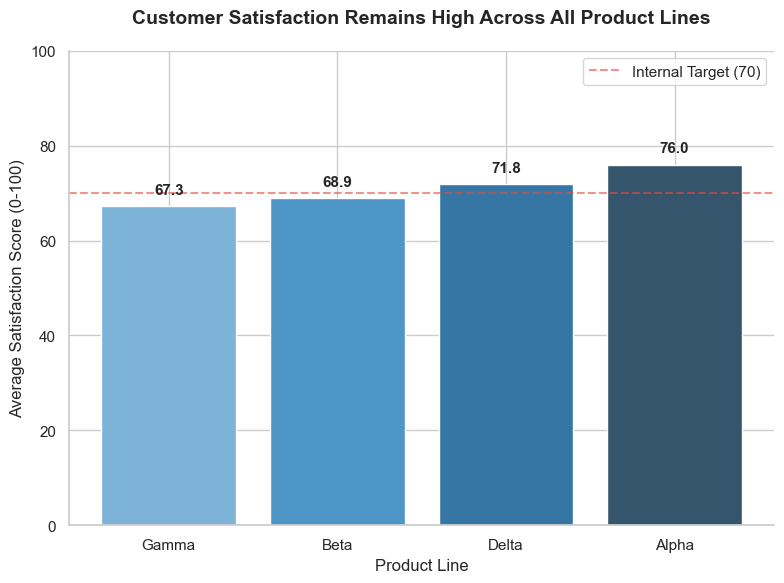

In [21]:
# TODO: Create your redesigned version of Chart 1
# Hints:
#   - Start the y-axis at 0 to show the true proportions
#   - Use a descriptive title that summarizes the actual finding
#   - Consider whether a bar chart is still the best choice



import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Assuming 'avg_sat' from your previous cell is available
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))

# Use a more neutral, professional color palette
colors = sns.color_palette("Blues_d", n_colors=len(avg_sat))

bars = ax.bar(avg_sat.index, avg_sat.values, color=colors, edgecolor='white')

# FIX 1: Start y-axis at 0 to show true scale
ax.set_ylim(0, 100) 

# FIX 2: Descriptive, objective title
ax.set_title("Customer Satisfaction Remains High Across All Product Lines", 
             fontsize=14, fontweight="bold", pad=20)

ax.set_ylabel("Average Satisfaction Score (0-100)")
ax.set_xlabel("Product Line")

# Add data labels for clarity
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
            f"{height:.1f}", ha="center", va="bottom", 
            fontsize=11, fontweight='bold')

# Add a reference line for a "Success Metric" (e.g., target score of 70)
ax.axhline(70, color="#e74c3c", linestyle="--", alpha=0.6, label="Internal Target (70)")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()


**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*
I set the y-axis baseline to **0** and expanded the limit to **100** to provide an honest visual proportion, demonstrating that the variance between products is a minor relative difference rather than a performance crisis.

### Redesign 2 — Fixing the Dual-Axis Chart

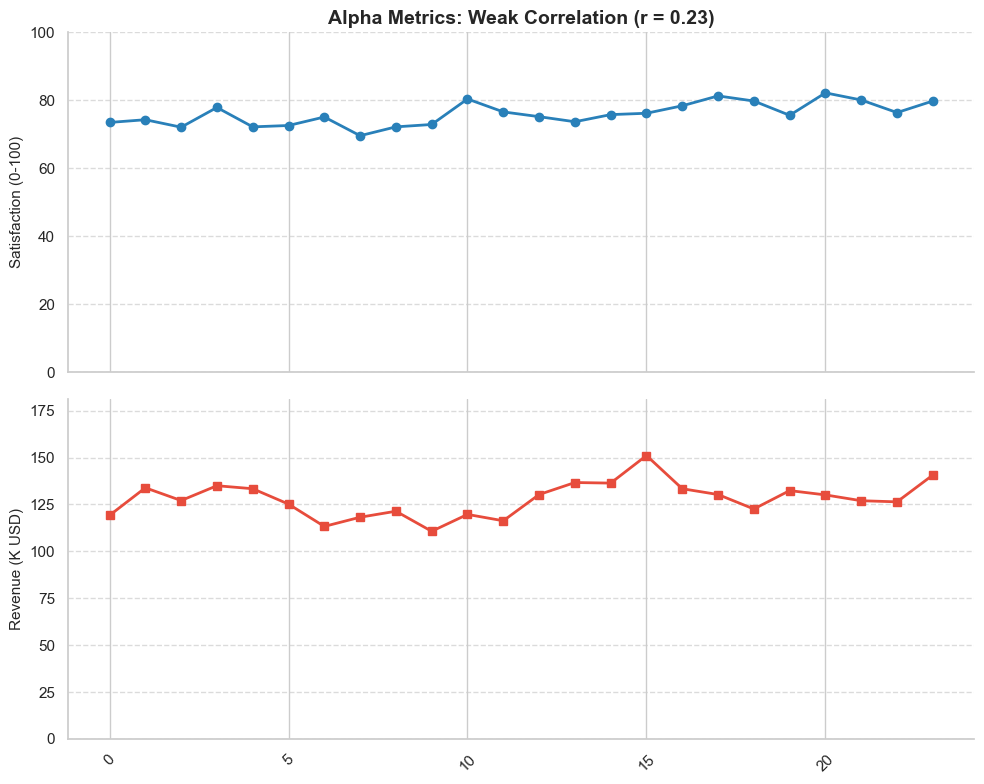

In [22]:
# TODO: Create your redesigned version of Chart 2
# Hints:
#   - Consider using two separate panels instead of overlapping axes
#   - If claiming a relationship, compute and show the actual correlation
#   - Normalize or use a shared scale if comparison is the goal


import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Prepare data
alpha = df[df["product"] == "Alpha"].copy()
corr, _ = pearsonr(alpha["satisfaction_score"], alpha["monthly_revenue"])

# Create a two-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel 1: Satisfaction
ax1.plot(alpha.index, alpha["satisfaction_score"], color="#2980b9", marker='o', linewidth=2)
ax1.set_ylabel("Satisfaction (0-100)", fontsize=11)
ax1.set_ylim(0, 100) # Full scale for honesty
ax1.set_title(f"Alpha Metrics: Weak Correlation (r = {corr:.2f})", fontsize=14, fontweight="bold")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Panel 2: Revenue
ax2.plot(alpha.index, alpha["monthly_revenue"], color="#e74c3c", marker='s', linewidth=2)
ax2.set_ylabel("Revenue (K USD)", fontsize=11)
ax2.set_ylim(0, alpha["monthly_revenue"].max() * 1.2) # Baseline at 0
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

I decoupled the variables into separate vertical panels and calculated the Pearson correlation coefficient ($r$) to replace the misleading visual overlap with an objective statistical measure of their relationship.

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

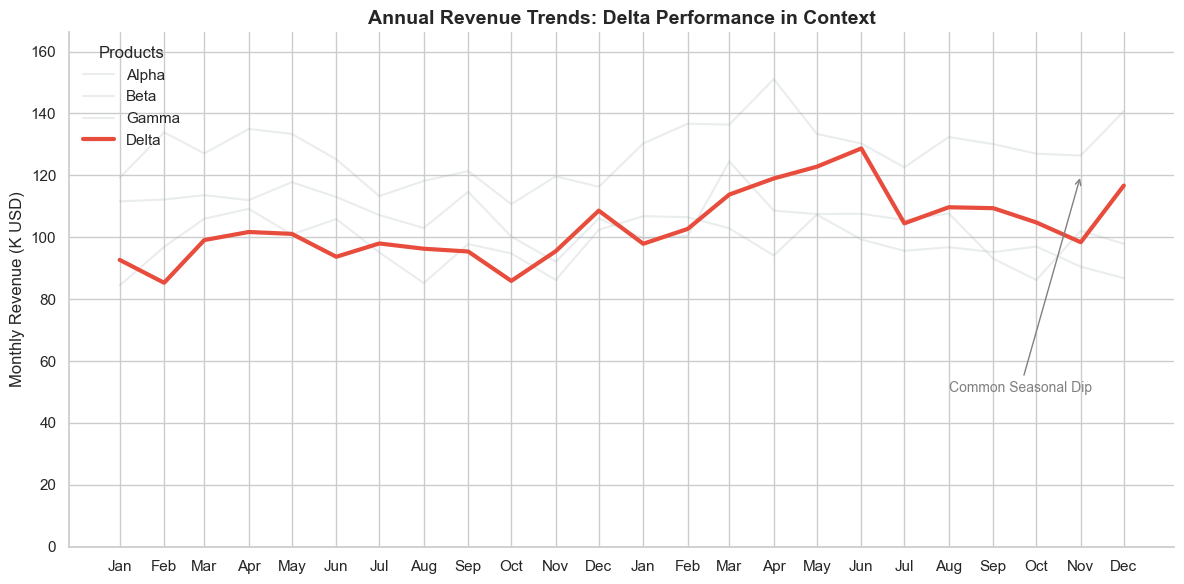

In [23]:
# TODO: Create your redesigned version of Chart 3
# Hints:
#   - Show the full time range so the audience sees the complete picture
#   - Consider adding other product lines for context
#   - Replace the filled area with a cleaner line plot if appropriate
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the full dataset for context
# Assuming 'df' contains the full 2024 data for all products
df['month'] = pd.to_datetime(df['month'])
full_year = df.sort_values("month")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all products in light gray to provide a baseline for "normal" behavior
for product in df["product"].unique():
    prod_data = full_year[full_year["product"] == product]
    alpha_val = 1.0 if product == "Delta" else 0.2
    color_val = "#e74c3c" if product == "Delta" else "#95a5a6"
    linewidth_val = 3 if product == "Delta" else 1.5
    
    ax.plot(prod_data["month"], prod_data["monthly_revenue"], 
            color=color_val, alpha=alpha_val, linewidth=linewidth_val, label=product)

# FIX 1: Show the full y-axis from 0 for honest scale
ax.set_ylim(0, df["monthly_revenue"].max() * 1.1)

# FIX 2: Objective title replacing the alarmist "Free Fall!"
ax.set_title("Annual Revenue Trends: Delta Performance in Context", fontsize=14, fontweight="bold")

# Formatting dates for readability
ax.set_ylabel("Monthly Revenue (K USD)")
plt.xticks(full_year["month"].unique(), [d.strftime('%b') for d in full_year["month"].unique()])

# Add a note about the year-end dip
ax.annotate("Common Seasonal Dip", 
            xy=(pd.Timestamp("2024-11-01"), 120), 
            xytext=(pd.Timestamp("2024-08-01"), 50),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10, color="gray")

ax.legend(title="Products", frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()


**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

I expanded the time horizon to the full fiscal year and included competitor product lines as a background reference, which reframes the late-year decline as a market-wide seasonal trend rather than a product-specific failure.

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [24]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

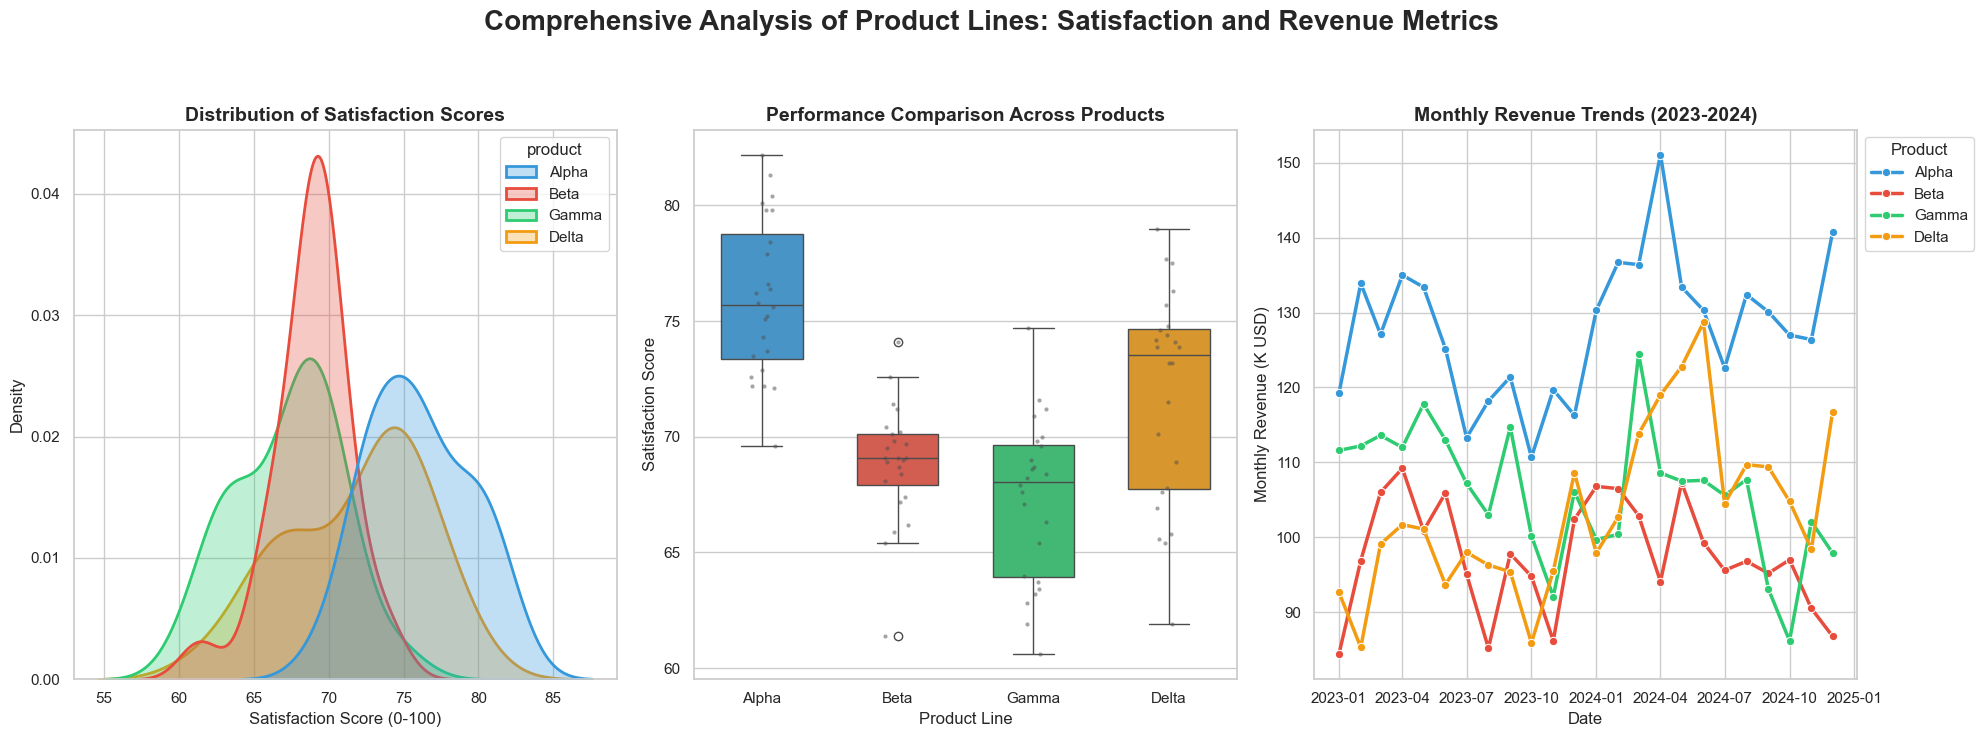

In [25]:
# TODO: Build the three-panel figure
#
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
#
# Panel 1 — Distribution
#   Suggested: overlapping histograms, KDE plots, or violin plots
#   Show where each product line sits within the overall satisfaction distribution
#
# Panel 2 — Comparison
#   Suggested: grouped bar chart with error bars, box plot, or strip plot
#   Show group means and their overlap/spread
#
# Panel 3 — Trend
#   Suggested: line plot with confidence bands
#   Show how monthly_revenue changes over time per product line
#
# fig.suptitle("...", fontsize=16, fontweight="bold", y=1.02)
# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

# Color palette for products
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel 1: Distribution ---
# KDE plot shows the density distribution of satisfaction scores
sns.kdeplot(
    data=df,
    x="satisfaction_score",
    hue="product",
    palette=palette,
    fill=True,
    alpha=0.3,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title("Distribution of Satisfaction Scores", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Satisfaction Score (0-100)")
axes[0].set_ylabel("Density")

# --- Panel 2: Comparison ---
# Box plot compares products 
sns.boxplot(
    data=df,
    x="product",
    y="satisfaction_score",
    hue="product",        
    palette=palette,
    ax=axes[1],
    width=0.6,
    legend=False          
)

# Add individual data points
sns.stripplot(
    data=df,
    x="product",
    y="satisfaction_score",
    color=".3",
    size=3,
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("Performance Comparison Across Products", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Satisfaction Score")

# --- Panel 3: Trend (Time Series) ---
# Line plot shows revenue changes over time
sns.lineplot(
    data=df,
    x="month",
    y="monthly_revenue",
    hue="product",
    palette=palette,
    linewidth=2.5,
    marker='o',
    markersize=6,
    ax=axes[2]
)

axes[2].set_title("Monthly Revenue Trends (2023-2024)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Monthly Revenue (K USD)")
axes[2].legend(title="Product", loc='upper left', bbox_to_anchor=(1, 1))

# Overall title
fig.suptitle(
    "Comprehensive Analysis of Product Lines: Satisfaction and Revenue Metrics",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | | |
| Title describes the finding, not just the variables | | |
| Axes are labeled with units | | |
| Color is used to encode meaning, not decoration | | |
| Uncertainty is shown where relevant (error bars, bands) | | |
| The chart can be understood without a verbal walkthrough | | |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | | |